In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set aesthetic visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

In [ ]:
baseline_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/baseline_test_full_2b_second/baseline_after_repair_results/metrics.json"
sft_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/inference/unified-sft-v1_test/sft_after_repair_results/metrics.json"

# Load JSONs
with open(baseline_path, "r") as f:
    baseline_data = json.load(f)

with open(sft_path, "r") as f:
    sft_data = json.load(f)


def get_comparison_df(keys, labels=None):
    """Helper to convert specific metric keys into a clean Pandas DataFrame."""
    rows = []
    for idx, key in enumerate(keys):
        label = labels[idx] if labels else key
        b_val = baseline_data.get(key, 0.0)
        s_val = sft_data.get(key, 0.0)
        diff = s_val - b_val
        pct_change = (
            (diff / b_val * 100)
            if b_val != 0
            else (100.0 if s_val > 0 else 0.0)
        )

        rows.append(
            {
                "Metric": label,
                "Baseline (2B)": b_val,
                "SFT LoRA": s_val,
                "Delta (Abs)": diff,
                "Delta (%)": pct_change,
            }
        )
    return pd.DataFrame(rows)


print("Metrics files loaded successfully!")

Metrics files loaded successfully!


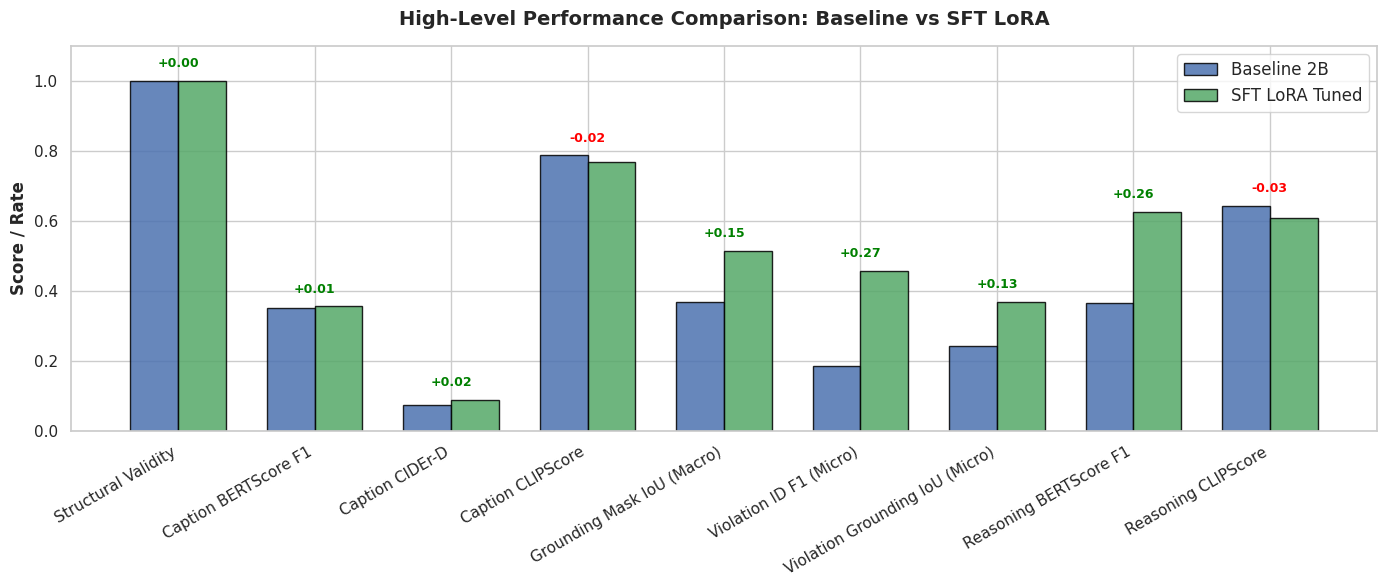

,Metric,Baseline (2B),SFT LoRA,Delta (Abs),Delta (%)
0,Structural Validity,1.000000,1.000000,0.000000,0.000000
1,Caption BERTScore F1,0.350809,0.356124,0.005314,1.514916
2,Caption CIDEr-D,0.073750,0.089863,0.016113,21.847870
3,Caption CLIPScore,0.787097,0.768082,-0.019014,-2.415755
4,Grounding Mask IoU (Macro),0.368439,0.515392,0.146954,39.885523
5,Violation ID F1 (Micro),0.187627,0.458194,0.270567,144.204624
6,Violation Grounding IoU (Micro),0.241981,0.369662,0.127681,52.764801
7,Reasoning BERTScore F1,0.366308,0.626718,0.260410,71.090424
8,Reasoning CLIPScore,0.643187,0.608612,-0.034575,-5.375608


In [ ]:
core_metrics = {
    "Structural Validity": "structural_json_validity_rate",
    "Caption BERTScore F1": "captioning_bertscore_f1",
    "Caption CIDEr-D": "captioning_ciderd",
    "Caption CLIPScore": "captioning_clipscore",
    "Grounding Mask IoU (Macro)": "grounding_mask_iou_exist_macro_mean",
    "Violation ID F1 (Micro)": "violation_identification_f1_micro",
    "Violation Grounding IoU (Micro)": "violation_grounding_mask_iou_micro_mean",
    "Reasoning BERTScore F1": "reasoning_text_similarity_bertscore_f1_micro",
    "Reasoning CLIPScore": "reasoning_text_similarity_clipscore_micro",
}

df_core = get_comparison_df(
    list(core_metrics.values()), list(core_metrics.keys())
)

# Plotting Side-by-Side Bar Chart
plt.figure(figsize=(14, 6))
x = np.arange(len(df_core))
width = 0.35

plt.bar(
    x - width / 2,
    df_core["Baseline (2B)"],
    width,
    label="Baseline 2B",
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85,
)
plt.bar(
    x + width / 2,
    df_core["SFT LoRA"],
    width,
    label="SFT LoRA Tuned",
    color="#55A868",
    edgecolor="black",
    alpha=0.85,
)

plt.ylabel("Score / Rate", fontsize=12, fontweight="bold")
plt.title(
    "High-Level Performance Comparison: Baseline vs SFT LoRA",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(x, df_core["Metric"], rotation=30, ha="right", fontsize=11)
plt.legend(fontsize=12)
plt.ylim(0, 1.1)
plt.tight_layout()

# Annotate value differences on top of bars
for i in range(len(df_core)):
    delta = df_core["Delta (Abs)"].iloc[i]
    color = "green" if delta >= 0 else "red"
    sign = "+" if delta >= 0 else ""
    plt.text(
        i,
        max(df_core["Baseline (2B)"].iloc[i], df_core["SFT LoRA"].iloc[i])
        + 0.03,
        f"{sign}{delta:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=color,
    )

plt.show()

# Display summary dataframe
display(df_core.style.background_gradient(cmap="Greens", subset=["Delta (Abs)"]))

/tmp/ipykernel_2533/3747101236.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(caption_labels, rotation=20)


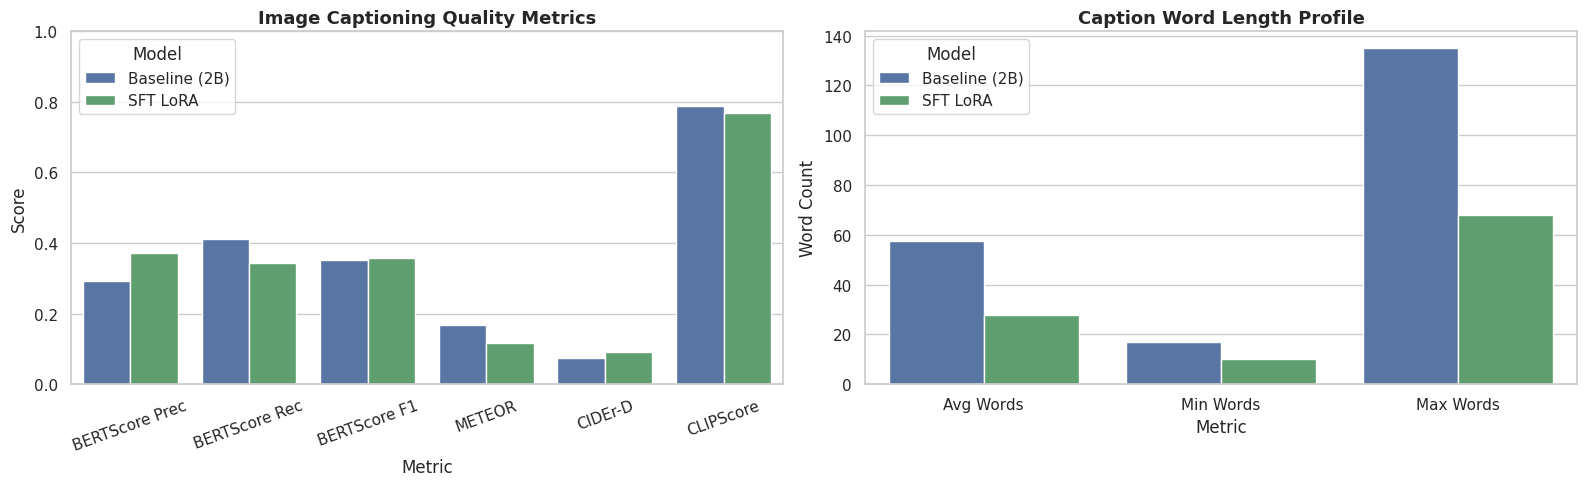

In [ ]:
caption_keys = [
    "captioning_bertscore_precision",
    "captioning_bertscore_recall",
    "captioning_bertscore_f1",
    "captioning_meteor",
    "captioning_ciderd",
    "captioning_clipscore",
]

caption_labels = [
    "BERTScore Prec",
    "BERTScore Rec",
    "BERTScore F1",
    "METEOR",
    "CIDEr-D",
    "CLIPScore",
]

df_cap = get_comparison_df(caption_keys, caption_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Captioning Quality Scores
df_cap_melted = pd.melt(
    df_cap,
    id_vars=["Metric"],
    value_vars=["Baseline (2B)", "SFT LoRA"],
    var_name="Model",
    value_name="Score",
)
sns.barplot(
    data=df_cap_melted,
    x="Metric",
    y="Score",
    hue="Model",
    ax=axes[0],
    palette=["#4C72B0", "#55A868"],
)
axes[0].set_title(
    "Image Captioning Quality Metrics", fontsize=13, fontweight="bold"
)
axes[0].set_xticklabels(caption_labels, rotation=20)
axes[0].set_ylim(0, 1.0)

# Plot 2: Caption Length Profile
length_metrics = {
    "Avg Words": "captioning_avg_words_per_caption",
    "Min Words": "captioning_min_words",
    "Max Words": "captioning_max_words",
}
df_len = get_comparison_df(
    list(length_metrics.values()), list(length_metrics.keys())
)
df_len_melted = pd.melt(
    df_len,
    id_vars=["Metric"],
    value_vars=["Baseline (2B)", "SFT LoRA"],
    var_name="Model",
    value_name="Word Count",
)

sns.barplot(
    data=df_len_melted,
    x="Metric",
    y="Word Count",
    hue="Model",
    ax=axes[1],
    palette=["#4C72B0", "#55A868"],
)
axes[1].set_title(
    "Caption Word Length Profile", fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

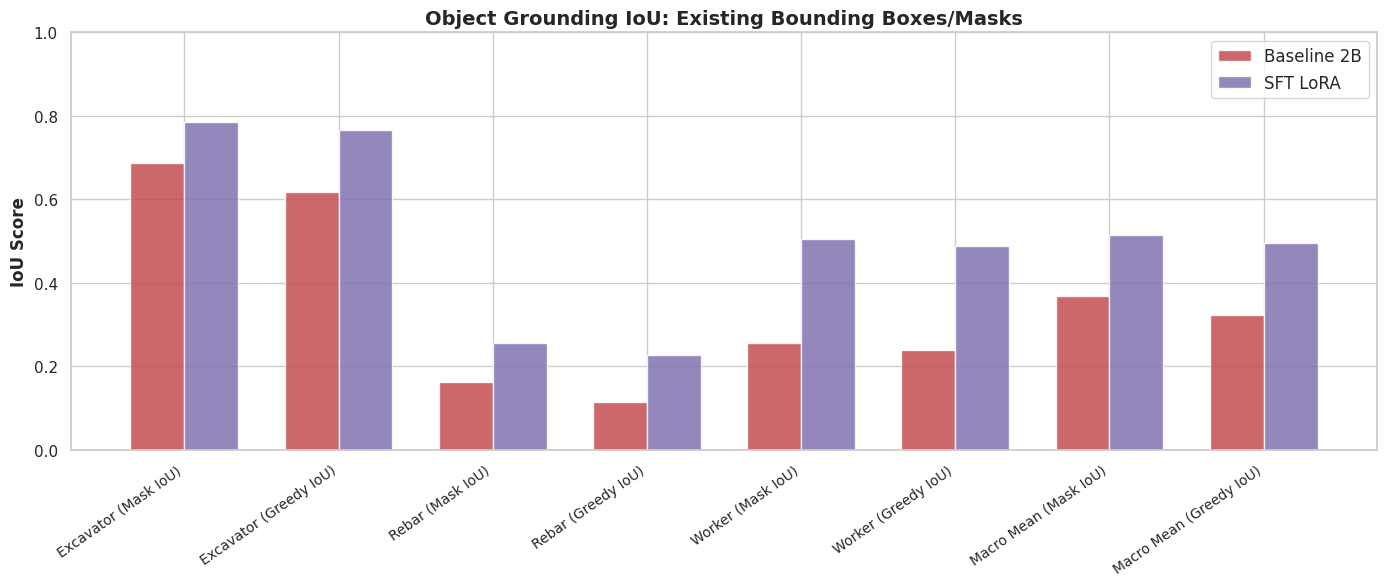

In [ ]:
grounding_keys = [
    ("Excavator (Mask IoU)", "grounding_mask_iou_exist_macro_excavator"),
    ("Excavator (Greedy IoU)", "grounding_greedy_iou_exist_macro_excavator"),
    ("Rebar (Mask IoU)", "grounding_mask_iou_exist_macro_rebar"),
    ("Rebar (Greedy IoU)", "grounding_greedy_iou_exist_macro_rebar"),
    (
        "Worker (Mask IoU)",
        "grounding_mask_iou_exist_macro_worker_with_white_hard_hat",
    ),
    (
        "Worker (Greedy IoU)",
        "grounding_greedy_iou_exist_macro_worker_with_white_hard_hat",
    ),
    ("Macro Mean (Mask IoU)", "grounding_mask_iou_exist_macro_mean"),
    ("Macro Mean (Greedy IoU)", "grounding_greedy_iou_exist_macro_mean"),
]

labels, keys = zip(*grounding_keys)
df_grd = get_comparison_df(list(keys), list(labels))

plt.figure(figsize=(14, 6))
x = np.arange(len(df_grd))
width = 0.35

plt.bar(
    x - width / 2,
    df_grd["Baseline (2B)"],
    width,
    label="Baseline 2B",
    color="#C44E52",
    alpha=0.85,
)
plt.bar(
    x + width / 2,
    df_grd["SFT LoRA"],
    width,
    label="SFT LoRA",
    color="#8172B0",
    alpha=0.85,
)

plt.ylabel("IoU Score", fontsize=12, fontweight="bold")
plt.title(
    "Object Grounding IoU: Existing Bounding Boxes/Masks",
    fontsize=14,
    fontweight="bold",
)
plt.xticks(x, df_grd["Metric"], rotation=35, ha="right", fontsize=10)
plt.legend(fontsize=12)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

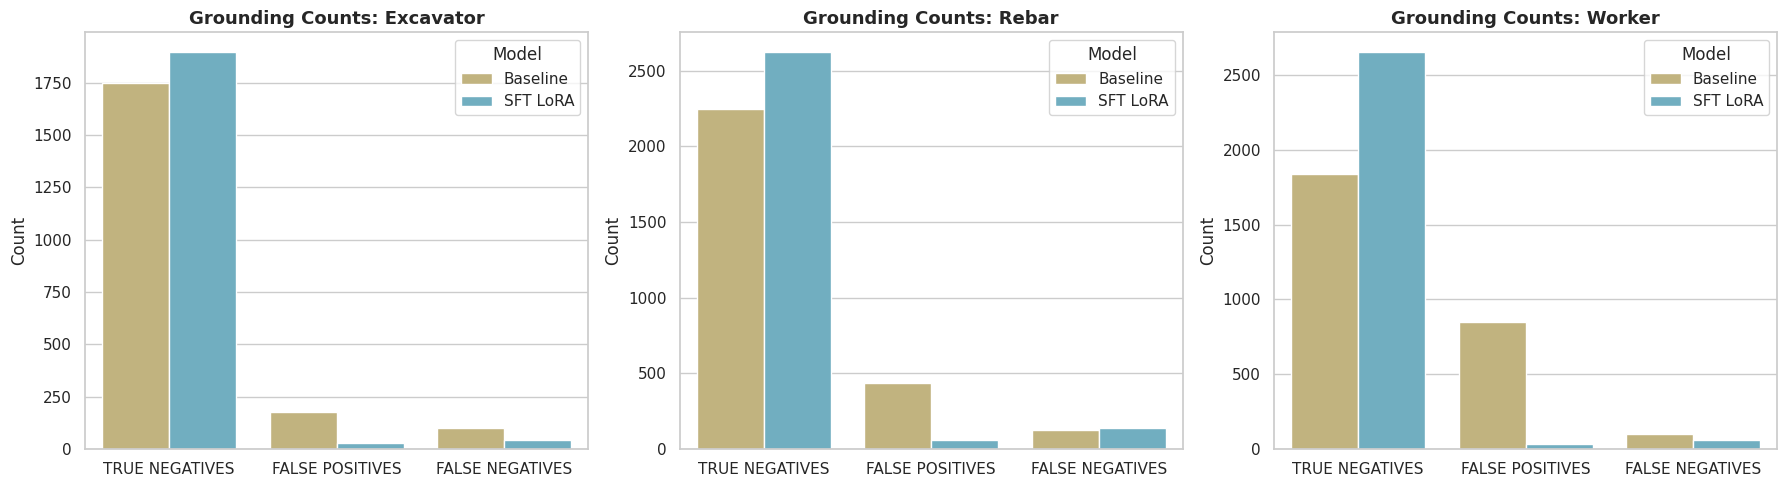

In [ ]:
categories = ["excavator", "rebar", "worker_with_white_hard_hat"]
count_types = ["true_negatives", "false_positives", "false_negatives"]

rows = []
for cat in categories:
    for ctype in count_types:
        key = f"grounding_{ctype}_count_{cat}"
        cat_clean = cat.replace("_with_white_hard_hat", "").capitalize()
        ctype_clean = ctype.replace("_count", "").replace("_", " ").upper()

        rows.append(
            {
                "Category": cat_clean,
                "Type": ctype_clean,
                "Baseline": baseline_data.get(key, 0),
                "SFT LoRA": sft_data.get(key, 0),
            }
        )

df_counts = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, cat in enumerate(df_counts["Category"].unique()):
    sub_df = df_counts[df_counts["Category"] == cat]
    sub_melted = pd.melt(
        sub_df,
        id_vars=["Type"],
        value_vars=["Baseline", "SFT LoRA"],
        var_name="Model",
        value_name="Count",
    )

    sns.barplot(
        data=sub_melted,
        x="Type",
        y="Count",
        hue="Model",
        ax=axes[idx],
        palette=["#CCB974", "#64B5CD"],
    )
    axes[idx].set_title(
        f"Grounding Counts: {cat}", fontsize=13, fontweight="bold"
    )
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

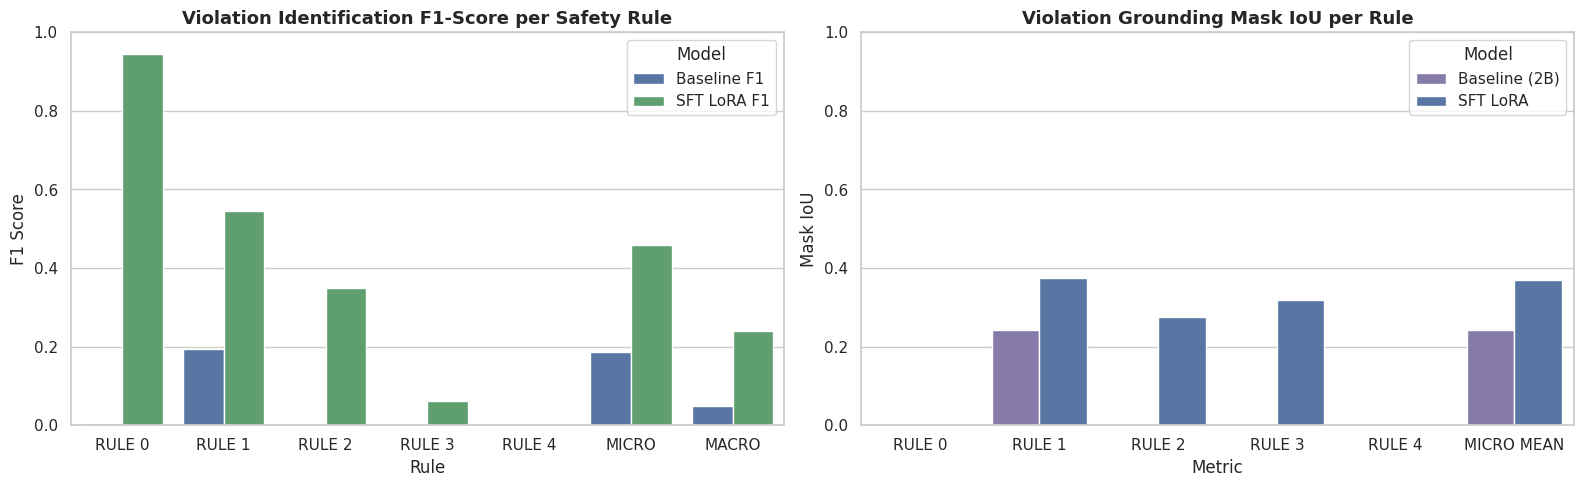

In [ ]:
rules = ["rule_0", "rule_1", "rule_2", "rule_3", "rule_4", "micro", "macro"]
violation_rows = []

for r in rules:
    p_key = f"violation_identification_precision_{r}"
    r_key = f"violation_identification_recall_{r}"
    f1_key = f"violation_identification_f1_{r}"

    violation_rows.append(
        {
            "Rule": r.replace("_", " ").upper(),
            "Baseline F1": baseline_data.get(f1_key, 0.0),
            "SFT LoRA F1": sft_data.get(f1_key, 0.0),
            "Baseline Rec": baseline_data.get(r_key, 0.0),
            "SFT LoRA Rec": sft_data.get(r_key, 0.0),
            "Baseline Prec": baseline_data.get(p_key, 0.0),
            "SFT LoRA Prec": sft_data.get(p_key, 0.0),
        }
    )

df_viol = pd.DataFrame(violation_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Violation F1
df_viol_f1 = pd.melt(
    df_viol,
    id_vars=["Rule"],
    value_vars=["Baseline F1", "SFT LoRA F1"],
    var_name="Model",
    value_name="F1 Score",
)
sns.barplot(
    data=df_viol_f1,
    x="Rule",
    y="F1 Score",
    hue="Model",
    ax=axes[0],
    palette=["#4C72B0", "#55A868"],
)
axes[0].set_title(
    "Violation Identification F1-Score per Safety Rule",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_ylim(0, 1.0)

# Plot Violation Grounding Mask IoU per Rule
v_ground_keys = [f"violation_grounding_mask_iou_{r}_micro" for r in rules[:5]]
v_ground_keys.append("violation_grounding_mask_iou_micro_mean")
v_ground_labels = [r.replace("_", " ").upper() for r in rules[:5]] + [
    "MICRO MEAN"
]

df_v_grd = get_comparison_df(v_ground_keys, v_ground_labels)
df_vg_melted = pd.melt(
    df_v_grd,
    id_vars=["Metric"],
    value_vars=["Baseline (2B)", "SFT LoRA"],
    var_name="Model",
    value_name="Mask IoU",
)

sns.barplot(
    data=df_vg_melted,
    x="Metric",
    y="Mask IoU",
    hue="Model",
    ax=axes[1],
    palette=["#8172B0", "#4C72B0"],
)
axes[1].set_title(
    "Violation Grounding Mask IoU per Rule", fontsize=13, fontweight="bold"
)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

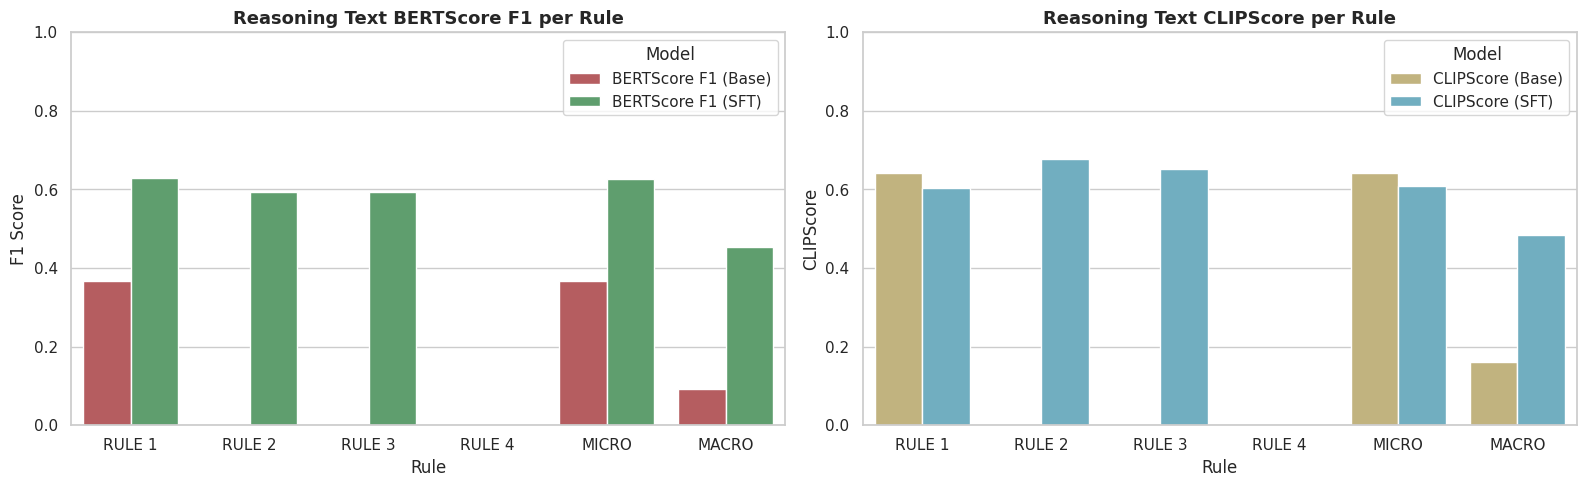

In [ ]:
reasoning_rules = [
    "rule_1",
    "rule_2",
    "rule_3",
    "rule_4",
    "micro",
    "macro",
]
r_rows = []

for r in reasoning_rules:
    b_f1 = f"reasoning_text_similarity_bertscore_f1_{r}"
    cider_key = f"reasoning_text_similarity_ciderd_{r}"
    clip_key = f"reasoning_text_similarity_clipscore_{r}"

    r_rows.append(
        {
            "Rule": r.replace("_", " ").upper(),
            "BERTScore F1 (Base)": baseline_data.get(b_f1, 0.0),
            "BERTScore F1 (SFT)": sft_data.get(b_f1, 0.0),
            "CLIPScore (Base)": baseline_data.get(clip_key, 0.0),
            "CLIPScore (SFT)": sft_data.get(clip_key, 0.0),
        }
    )

df_reason = pd.DataFrame(r_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BERTScore F1 Reasoning Comparison
df_r_f1 = pd.melt(
    df_reason,
    id_vars=["Rule"],
    value_vars=["BERTScore F1 (Base)", "BERTScore F1 (SFT)"],
    var_name="Model",
    value_name="F1 Score",
)
sns.barplot(
    data=df_r_f1,
    x="Rule",
    y="F1 Score",
    hue="Model",
    ax=axes[0],
    palette=["#C44E52", "#55A868"],
)
axes[0].set_title(
    "Reasoning Text BERTScore F1 per Rule", fontsize=13, fontweight="bold"
)
axes[0].set_ylim(0, 1.0)

# CLIPScore Reasoning Comparison
df_r_clip = pd.melt(
    df_reason,
    id_vars=["Rule"],
    value_vars=["CLIPScore (Base)", "CLIPScore (SFT)"],
    var_name="Model",
    value_name="CLIPScore",
)
sns.barplot(
    data=df_r_clip,
    x="Rule",
    y="CLIPScore",
    hue="Model",
    ax=axes[1],
    palette=["#CCB974", "#64B5CD"],
)
axes[1].set_title(
    "Reasoning Text CLIPScore per Rule", fontsize=13, fontweight="bold"
)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

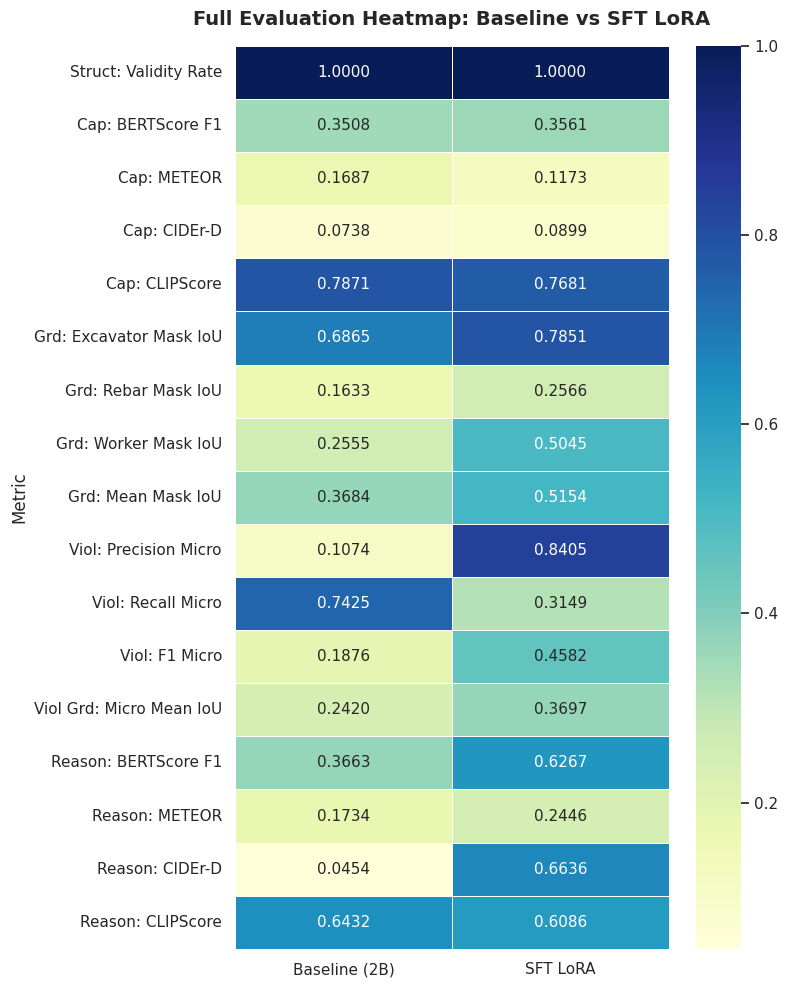


                       SUMMARY DELTA TABLE


,Metric,Baseline (2B),SFT LoRA,Delta (Abs),Delta (%)
0,Struct: Validity Rate,1.0000,1.0000,+0.0000,+0.00%
1,Cap: BERTScore F1,0.3508,0.3561,+0.0053,+1.51%
2,Cap: METEOR,0.1687,0.1173,-0.0514,-30.46%
3,Cap: CIDEr-D,0.0738,0.0899,+0.0161,+21.85%
4,Cap: CLIPScore,0.7871,0.7681,-0.0190,-2.42%
5,Grd: Excavator Mask IoU,0.6865,0.7851,+0.0985,+14.35%
6,Grd: Rebar Mask IoU,0.1633,0.2566,+0.0933,+57.15%
7,Grd: Worker Mask IoU,0.2555,0.5045,+0.2490,+97.46%
8,Grd: Mean Mask IoU,0.3684,0.5154,+0.1470,+39.89%
9,Viol: Precision Micro,0.1074,0.8405,+0.7331,+682.72%


In [ ]:
# Selected representative key metrics across all domains
all_summary_keys = {
    "Struct: Validity Rate": "structural_json_validity_rate",
    "Cap: BERTScore F1": "captioning_bertscore_f1",
    "Cap: METEOR": "captioning_meteor",
    "Cap: CIDEr-D": "captioning_ciderd",
    "Cap: CLIPScore": "captioning_clipscore",
    "Grd: Excavator Mask IoU": "grounding_mask_iou_exist_macro_excavator",
    "Grd: Rebar Mask IoU": "grounding_mask_iou_exist_macro_rebar",
    "Grd: Worker Mask IoU": "grounding_mask_iou_exist_macro_worker_with_white_hard_hat",
    "Grd: Mean Mask IoU": "grounding_mask_iou_exist_macro_mean",
    "Viol: Precision Micro": "violation_identification_precision_micro",
    "Viol: Recall Micro": "violation_identification_recall_micro",
    "Viol: F1 Micro": "violation_identification_f1_micro",
    "Viol Grd: Micro Mean IoU": "violation_grounding_mask_iou_micro_mean",
    "Reason: BERTScore F1": "reasoning_text_similarity_bertscore_f1_micro",
    "Reason: METEOR": "reasoning_text_similarity_meteor_micro",
    "Reason: CIDEr-D": "reasoning_text_similarity_ciderd_micro",
    "Reason: CLIPScore": "reasoning_text_similarity_clipscore_micro",
}

df_full_summary = get_comparison_df(
    list(all_summary_keys.values()), list(all_summary_keys.keys())
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    df_full_summary.set_index("Metric")[["Baseline (2B)", "SFT LoRA"]],
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar=True,
    linewidths=0.5,
)
plt.title(
    "Full Evaluation Heatmap: Baseline vs SFT LoRA",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

# Print formatted summary table with absolute and percentage gains
print("\n" + "=" * 80)
print("                       SUMMARY DELTA TABLE")
print("=" * 80)
display(
    df_full_summary.style.format(
        {
            "Baseline (2B)": "{:.4f}",
            "SFT LoRA": "{:.4f}",
            "Delta (Abs)": "{:+.4f}",
            "Delta (%)": "{:+.2f}%",
        }
    ).background_gradient(cmap="RdYlGn", subset=["Delta (Abs)"])
)